In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import minmaxscaler
from sklearn.preprocessing import MinMaxScaler
#import svr
from sklearn.svm import SVR
#import pipelines
from sklearn.pipeline import make_pipeline


In [63]:
def load_data(path):
    df=pd.read_csv(path)
    df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"])
    df = df.sort_values("TEST_DATE").dropna(subset=["OIL"]).reset_index(drop=True)
    df = df[df["OIL"] > 0].reset_index(drop=True)
    return df

In [64]:
def visualize_data(df):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x="TEST_DATE", y="OIL", data=df)
    plt.title("Oil Production Over Time")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.show()

In [65]:
def create_dataset(feature_series, target_series, time_steps=30):
    Xs, ys, indices = [], [], []
    for i in range(time_steps, len(feature_series)):
        Xs.append(feature_series[i - time_steps:i])
        ys.append(target_series[i])
        indices.append(i)
    return np.array(Xs), np.array(ys), np.array(indices)

/tmp/ipykernel_211799/2224772952.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"])


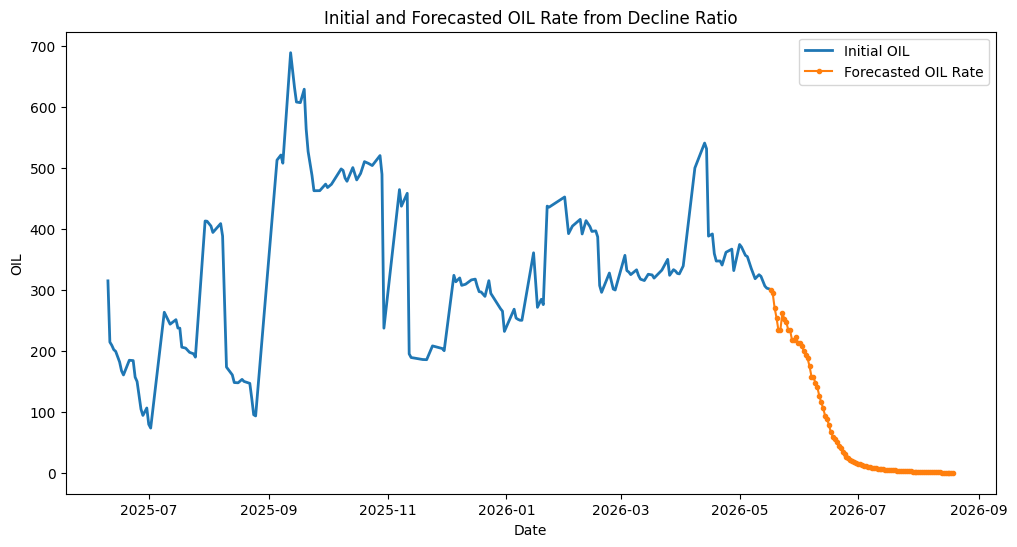

In [66]:
def main():
    # Load data
    path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"
    df = load_data(path)
    df['LN_OIL'] = np.log(df['OIL'])
    df['DEC_RATIO'] = np.log(df['OIL'].shift(-1) / df['OIL'])
    df.loc[df['DEC_RATIO'] > 0, 'DEC_RATIO'] = np.nan
    df = df.dropna(subset=['DEC_RATIO']).reset_index(drop=True)

    # Split data with 80% for training and 20% for testing
    train_size = int(len(df) * 0.8)
    feature_series = df["LN_OIL"].values
    target_series = df["DEC_RATIO"].values

    # Create supervised features with a rolling window of 30 past LN_OIL values
    # and target as decline ratio ln(q(t+1)/q(t)).
    time_steps = 30
    X_all, y_all, target_indices = create_dataset(feature_series, target_series, time_steps=time_steps)

    train_mask = target_indices < train_size
    X_train, y_train = X_all[train_mask], y_all[train_mask]

    # Train SVR model in decline-ratio space
    model = make_pipeline(MinMaxScaler(), SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1))
    model.fit(X_train, y_train)

    # Recursive forecasting in decline-ratio space; convert predicted decline ratio to OIL rate.
    future_oil_predictions = []
    future_dates = []
    history_ln = feature_series[-time_steps:].tolist()
    q_t = np.exp(history_ln[-1])

    freq = pd.infer_freq(df["TEST_DATE"]) or 'D'
    date_offset = pd.tseries.frequencies.to_offset(freq)
    current_date = df["TEST_DATE"].iloc[-1]

    # Stop forecasting when OIL reaches 25.
    stop_oil = 1
    max_steps = 10000

    for _ in range(max_steps):
        if q_t <= stop_oil:
            break

        current_input = np.array(history_ln[-time_steps:]).reshape(1, -1)
        pred_dec_ratio = model.predict(current_input)[0]

        # Use ln(q(t+1)/q(t)) directly: q(t+1) = q(t) * exp(decline_ratio).
        q_t = q_t * np.exp(pred_dec_ratio)
        current_date = current_date + date_offset

        if q_t <= stop_oil:
            q_t = stop_oil
            future_oil_predictions.append(q_t)
            future_dates.append(current_date)
            break

        future_oil_predictions.append(q_t)
        future_dates.append(current_date)
        history_ln.append(np.log(q_t))

    # Plot initial data and the forecasted rate.
    plt.figure(figsize=(12, 6))
    plt.plot(df["TEST_DATE"], df["OIL"], label="Initial OIL", linewidth=2)
    if len(future_oil_predictions) > 0:
        plt.plot(future_dates, future_oil_predictions, label="Forecasted OIL Rate", marker='o', markersize=3)
    plt.title("Initial and Forecasted OIL Rate from Decline Ratio")
    plt.xlabel("Date")
    plt.ylabel("OIL")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()